# Field-aligned proton and alpha beams at a solar-wind current sheet
### Solar Orbiter · 2025-02-28 · 11:55–11:57 UTC

**Case study.** Solar Orbiter crosses a current sheet in the fast-to-slow solar wind behind the
2025-02-28 disturbance shown in the "Event context" slide (N. Fargette & the PAS team, Arcachon 2026).
During the B_L reversal, SWA-PAS sees a **proton beam** and an **alpha (He²⁺) beam** next to the
core populations. This notebook locates the interval, identifies the four populations in the PAS spectra,
measures their speeds, and looks at them in field-aligned 3D velocity distributions with the
`sciqlop_vdf` plugin.

| result (11:55–11:57 UTC) | value |
|---|---|
| beam detection, protons | 11:55:21 – 11:56:41 |
| proton beam speed | 765 km/s [734–773] |
| alpha beam speed | 752 km/s [725–770] |
| beam − core, protons / alphas | +140 / +121 km/s |
| local Alfvén speed | 141 km/s (\|B\| = 24.9 nT, n = 14.8 cm⁻³) |
| E/q ratio alpha beam / proton beam | 1.93 (2.00 = same speed) |
| beam direction in the VDF | along +B (≈ +R, anti-sunward), Δv∥ ≈ +145 km/s |

<sub>Medians with [10th–90th percentile]. Every number is recomputed by the cells below.</sub>

**Contents**
0. Setup · helpers · virtual products
1. Event context — the slide, reproduced
2. Locating the current sheet and the beam interval
3. Identifying protons and alphas in the PAS spectra
4. 3D distributions in the field-aligned frame
5. Interpretation · caveats · provenance

> **Running it.** Execute top to bottom inside SciQLop. Panels are re-created on each run
> (`fresh_panel`). Section 4 needs the [sciqlop-vdf](https://github.com/nicolasaunai/sciqlop-vdf) plugin (≥ 0.2.0, with its Solar Orbiter adapter); the PAS VDF daily file is ~180 MB on disk and ~3 GB in memory once decoded.

## 0 · Setup

In [39]:
%matplotlib inline
import sys, pathlib, dataclasses, time
import numpy as np
import pandas as pd
import scipy.constants as cst
import speasy as spz
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display
from scipy.signal import find_peaks
from speasy.products import SpeasyVariable, VariableTimeAxis, VariableAxis, DataContainer
from PySide6.QtCore import Qt
from PySide6.QtGui import QColor
from SciQLop.user_api.plot import (create_plot_panel, plot_panel, list_plot_panels, TimeRange, ScaleType,
                                   Text, CoordinateSystem)
from SciQLop.user_api.threading import invoke_on_main_thread

# --- products ------------------------------------------------------------------------------------
SOLO = "speasy//cda//Solar_Orbiter//SOLO"
MAG_RTN   = SOLO + "//MAG//SOLO_L2_MAG_RTN_NORMAL//B_RTN"                # 8 vec/s
PAS_MOM   = SOLO + "//SWA_PAS//SOLO_L2_SWA_PAS_GRND_MOM"                 # 1 s moments
PAS_V, PAS_N, PAS_T = PAS_MOM + "//V_RTN", PAS_MOM + "//N", PAS_MOM + "//T"
PAS_EFLUX = SOLO + "//SWA_PAS//SOLO_L2_SWA_PAS_EFLUX//eflux"              # 1 s, 96 E/q bins
EAS_NMPAD = SOLO + "//swa_eas_nmpad_psd//SOLO_L3_SWA_EAS_NMPAD_PSD//SWA_EAS_NMPAD_PSD_DATA"
TREE = spz.inventories.tree.cda.Solar_Orbiter.SOLO

# --- time windows --------------------------------------------------------------------------------
OVERVIEW   = ("2025-02-27T03:00:00", "2025-03-02T02:00:00")   # the slide (read off its ticks, ±~1 h)
ZOOM       = ("2025-02-28T11:51:44", "2025-02-28T12:00:18")   # current sheet
ID_WINDOW  = ("2025-02-28T11:55:00", "2025-02-28T11:57:00")   # proton / alpha identification only here
AVG_WINDOW = ("2025-02-28T11:55:25", "2025-02-28T11:56:35")   # averaged distributions
MARKER_T   = "2025-02-28T11:55:49.5"                           # single distribution
ID_WINDOW_NS = tuple(np.datetime64(t, "ns") for t in ID_WINDOW)
E_SPLIT = 3600.0   # eV/q: above the highest proton-beam E/q (≈3.4 keV), below the lowest alpha-core E/q (≈4.0 keV)

def epoch(t):
    return np.datetime64(t, "ns").astype(np.int64) / 1e9

def fresh_panel(name):
    """Re-runnable: close a previous panel with the same name, then create it."""
    if name in list_plot_panels():
        plot_panel(name).close()
    return create_plot_panel(name)

# --- figure style: reference categorical palette (validated: CVD and normal-vision separation pass;
#     aqua/yellow are below 3:1 contrast, so every series is also direct-labelled or tabulated) -------
POP = {"p core": "#2a78d6", "p beam": "#eb6834", "alpha core": "#1baf7a", "alpha beam": "#eda100"}
POP_LS = {"p core": "-", "p beam": "-", "alpha core": "--", "alpha beam": "--"}
BCOL = {"B_L": "#4a3aa7", "B_M": "#e87ba4", "B_N": "#008300"}
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10.5, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})
pd.set_option("display.precision", 1)
print("speasy", spz.__version__)

speasy 1.9.0


### Helpers
* **`mva_basis(b, start, stop)`** — minimum-variance analysis of B over a window. Rows of the basis are
  L (max variance), M, N (min variance) in RTN. Signs are fixed so the frame does not flip between windows:
  N_R ≥ 0, L's largest component > 0, M = N × L. Cached per window, so B and V share one basis.
  N is trustworthy only if λ_int/λ_min ≳ 5–10 (Sonnerup & Scheible 1998).
* **`track_beams(E, F)`** — per 1 s PAS spectrum: proton core = eflux maximum E₀; proton beam, alpha core,
  alpha beam = strongest peak (prominence ≥ 0.15 dex) in the E/q windows 1.25–1.75, 1.8–2.3 and 2.45–3.5 × E₀.
  Beams must be within 1.5 / 1.3 dex of their core. Peaks refined below the bin size with a parabola in log F – log E.
* **`speed(E_q, A, Z)`** — v = √(2 Z e (E/q) / (A m_p)).

In [40]:
# --- MVA ----------------------------------------------------------------------------------------
_MVA_CACHE, MVA_LAST = {}, {}

def mva_basis(b, start, stop):
    """MVA of B (RTN) on [start, stop] (epoch s) -> (basis rows L, M, N in RTN, eigenvalues desc, n)."""
    key = (round(float(start), 3), round(float(stop), 3))
    if key in _MVA_CACHE:
        return _MVA_CACHE[key]
    t = b.time.astype("datetime64[ns]").astype(np.int64) / 1e9
    x = np.asarray(b.values, dtype=float)
    ok = (t >= start) & (t <= stop) & np.all(np.isfinite(x), axis=1)
    if ok.sum() < 10:
        return None
    w, v = np.linalg.eigh(np.cov(x[ok], rowvar=False, bias=True))
    lam = w[::-1]
    L, _, N = v[:, ::-1].T
    N = -N if N[0] < 0 else N
    L = -L if L[np.argmax(np.abs(L))] < 0 else L
    res = (np.vstack([L, np.cross(N, L), N]), lam, int(ok.sum()))
    _MVA_CACHE[key] = res
    if len(_MVA_CACHE) > 64:
        _MVA_CACHE.pop(next(iter(_MVA_CACHE)))
    MVA_LAST.update(start=start, stop=stop, L=res[0][0], M=res[0][1], N=res[0][2], lam=lam, n=res[2])
    return res

def to_lmn(v, basis, name, unit, prefix):
    return SpeasyVariable(axes=[VariableTimeAxis(values=v.time.copy())],
                          values=DataContainer(values=np.asarray(v.values, float) @ basis.T, name=name, meta={"UNITS": unit}),
                          columns=[f"{prefix}_L", f"{prefix}_M", f"{prefix}_N"])

# --- beam tracker -------------------------------------------------------------------------------
BEAM_WINDOWS = {"p_beam": (1.25, 1.75), "a_core": (1.8, 2.3), "a_beam": (2.45, 3.5)}   # x E0
PEAK_PROMINENCE, P_BEAM_DROP, A_BEAM_DROP = 0.15, 1.5, 1.3                             # dex

def _refine(logE, lf, p):
    if 0 < p < len(lf) - 1 and np.all(np.isfinite(lf[p - 1:p + 2])):
        a, b, _ = np.polyfit(logE[p - 1:p + 2], lf[p - 1:p + 2], 2)
        if a < 0 and logE[p - 1] <= -b / (2 * a) <= logE[p + 1]:
            return 10 ** (-b / (2 * a))
    return 10 ** logE[p]

def track_beams(E_asc, F_asc):
    """E/q [eV] of (p core, p beam, alpha core, alpha beam) per spectrum; NaN where absent."""
    logE = np.log10(E_asc)
    out = np.full((F_asc.shape[0], 4), np.nan)
    for k, f in enumerate(F_asc):
        lf = np.log10(np.where(f > 0, f, np.nan))
        if not np.isfinite(lf).any():
            continue
        p0 = int(np.nanargmax(lf)); E0 = _refine(logE, lf, p0); out[k, 0] = E0
        pk, _ = find_peaks(np.nan_to_num(lf, nan=np.nanmin(lf)), prominence=PEAK_PROMINENCE)
        def best(key):
            lo, hi = BEAM_WINDOWS[key]
            sel = [p for p in pk if lo * E0 <= E_asc[p] <= hi * E0]
            return max(sel, key=lambda q: lf[q]) if sel else None
        pa, pb, ab = best("a_core"), best("p_beam"), best("a_beam")
        if pa is not None:
            out[k, 2] = _refine(logE, lf, pa)
        if pb is not None and lf[pb] >= lf[p0] - P_BEAM_DROP:
            out[k, 1] = _refine(logE, lf, pb)
        if ab is not None and pa is not None and lf[ab] >= lf[pa] - A_BEAM_DROP:
            out[k, 3] = _refine(logE, lf, ab)
    return out

def speed(E_q, A, Z):
    """km/s from E/q [eV], mass number A, charge Z."""
    return np.sqrt(2 * Z * cst.e * np.asarray(E_q, float) / (A * cst.m_p)) / 1e3

def pas_eflux(t0, t1):
    """PAS eflux as (time, E ascending, F[t, E])."""
    e = spz.get_data(TREE.SWA_PAS.SOLO_L2_SWA_PAS_EFLUX.eflux, t0, t1)
    E = np.asarray(e.axes[1].values, float); o = np.argsort(E)
    return e.time, E[o], np.asarray(e.values, float)[:, o]

def direct_labels(ax, x, ys, labels, min_sep, log=False):
    """End-of-line labels, nudged apart vertically (min_sep in data units, or in decades if log), on a surface chip."""
    ys = np.log10(ys) if log else np.asarray(ys, float)
    order = np.argsort(ys); placed = ys.copy()
    for a, b in zip(order[:-1], order[1:]):
        if placed[b] - placed[a] < min_sep:
            placed[b] = placed[a] + min_sep
    for y, lab in zip(placed, labels):
        ax.annotate(lab, (x, 10 ** y if log else y), xytext=(6, 0), textcoords="offset points", va="center",
                    fontsize=10, color=INK, annotation_clip=False,
                    bbox=dict(boxstyle="round,pad=0.15", fc=SURF, ec="none", alpha=0.9))

def stat(x):
    x = np.asarray(x, float)
    return f"{np.nanmedian(x):.0f} [{np.nanpercentile(x, 10):.0f}–{np.nanpercentile(x, 90):.0f}]"

# --- SciQLop line styling (not in user_api: set the graph pens on the GUI thread) --------------------
def style_graph(panel_name, plot_index, graph_name, width=2.0, colors=None, styles=None):
    def _apply():
        pl = plot_panel(panel_name).plots[plot_index]
        for g in pl.graphs:
            if g.name == graph_name:
                for i, c in enumerate(g._get_impl_or_raise().components()):
                    pen = c.pen(); pen.setWidthF(width)
                    if colors: pen.setColor(QColor(colors[i]))
                    if styles: pen.setStyle(styles[i])
                    c.set_pen(pen)
        pl.replot()
    invoke_on_main_thread(_apply)

def thicken_all_lines(panel_name, width=2.0):
    for i, pl in enumerate(plot_panel(panel_name).plots):
        for g in pl.graphs:
            if type(g).__name__ == "Graph":
                style_graph(panel_name, i, g.name, width)

### Virtual products
Each is recomputed for the time range on screen. `B_LMN` / `V_LMN` redo the MVA on every new window;
the beam products only fill `ID_WINDOW`.

| path | content |
|---|---|
| `solo//eas_pad_327_753eV` | electron PAD, mean PSD over the EAS bins 326.6–753.1 eV |
| `solo//pas_eflux_spectro` | PAS eflux as a (time, energy) spectrogram |
| `solo//B_LMN`, `solo//V_LMN` | B and V in the window-MVA frame |
| `solo//alpha_energy` | expected E/q of He²⁺ co-moving with the protons |
| `solo//pas_beam_energies` | tracked E/q of the four populations |
| `solo//pas_beam_speeds` | proton- and alpha-beam speeds |

In [41]:
%%vp --path "solo/eas_pad_327_753eV"
from typing import Annotated
import numpy as np
from speasy.products import SpeasyVariable, VariableTimeAxis, VariableAxis, DataContainer
from SciQLop.user_api.virtual_products import Depends

NMPAD = "speasy//cda//Solar_Orbiter//SOLO//swa_eas_nmpad_psd//SOLO_L3_SWA_EAS_NMPAD_PSD//SWA_EAS_NMPAD_PSD_DATA"

def eas_pad_327_753eV(start: float, stop: float,
                      v: Annotated[SpeasyVariable, Depends(NMPAD)]) -> Spectrogram["PAD 327-753 eV"]:
    if v is None or len(v) == 0:
        return None
    E = v.axes[2].values
    sel = (E >= 320.0) & (E <= 760.0)
    f = np.where(np.isfinite(v.values) & (v.values > 0), v.values, np.nan)[:, :, sel]
    return SpeasyVariable(
        axes=[VariableTimeAxis(values=v.time.copy()),
              VariableAxis(values=v.axes[1].values.copy(), name="pitch_angle", meta={"UNITS": "deg"})],
        values=DataContainer(values=np.nanmean(f, axis=2), name="PAD_327_753eV",
                             meta={"UNITS": "s^3 km^-6", "DISPLAY_TYPE": "spectrogram"}))

In [42]:
%%vp --path "solo/pas_eflux_spectro"
from typing import Annotated
import numpy as np
from speasy.products import SpeasyVariable, VariableTimeAxis, VariableAxis, DataContainer
from SciQLop.user_api.virtual_products import Depends

EFLUX = "speasy//cda//Solar_Orbiter//SOLO//SWA_PAS//SOLO_L2_SWA_PAS_EFLUX//eflux"

def pas_eflux_spectro(start: float, stop: float,
                      e: Annotated[SpeasyVariable, Depends(EFLUX)]) -> Spectrogram["PAS eflux"]:
    if e is None or len(e) == 0:
        return None
    E = np.asarray(e.axes[1].values); o = np.argsort(E)
    vals = np.asarray(e.values, dtype=float)[:, o]
    vals[~(vals > 0)] = np.nan
    return SpeasyVariable(
        axes=[VariableTimeAxis(values=e.time.copy()), VariableAxis(values=E[o].copy(), name="energy", meta={"UNITS": "eV"})],
        values=DataContainer(values=vals, name="PAS_eflux",
                             meta={"UNITS": "cm-2 s-1 eV/eV", "DISPLAY_TYPE": "spectrogram", "SCALETYP": "log"}))

In [43]:
%%vp --path "solo/B_LMN"
from typing import Annotated
from speasy.products import SpeasyVariable
from SciQLop.user_api.virtual_products import Depends

MAGN = "speasy//cda//Solar_Orbiter//SOLO//MAG//SOLO_L2_MAG_RTN_NORMAL//B_RTN"

def B_LMN(start: float, stop: float,
          b: Annotated[SpeasyVariable, Depends(MAGN)]) -> Vector["B_L", "B_M", "B_N"]:
    if b is None or len(b) == 0:
        return None
    r = mva_basis(b, start, stop)
    return None if r is None else to_lmn(b, r[0], "B_LMN", "nT", "B")

In [44]:
%%vp --path "solo/V_LMN"
from typing import Annotated
from speasy.products import SpeasyVariable
from SciQLop.user_api.virtual_products import Depends

MAGN = "speasy//cda//Solar_Orbiter//SOLO//MAG//SOLO_L2_MAG_RTN_NORMAL//B_RTN"
VRTN = "speasy//cda//Solar_Orbiter//SOLO//SWA_PAS//SOLO_L2_SWA_PAS_GRND_MOM//V_RTN"

def V_LMN(start: float, stop: float,
          v: Annotated[SpeasyVariable, Depends(VRTN)],
          b: Annotated[SpeasyVariable, Depends(MAGN)]) -> Vector["V_L", "V_M", "V_N"]:
    if v is None or b is None or len(v) == 0 or len(b) == 0:
        return None
    r = mva_basis(b, start, stop)          # same cached basis as B_LMN
    return None if r is None else to_lmn(v, r[0], "V_LMN", "km/s", "V")

In [45]:
%%vp --path "solo/alpha_energy"
from typing import Annotated
import numpy as np
import scipy.constants as cst
from speasy.products import SpeasyVariable, VariableTimeAxis, DataContainer
from SciQLop.user_api.virtual_products import Depends

VRTN = "speasy//cda//Solar_Orbiter//SOLO//SWA_PAS//SOLO_L2_SWA_PAS_GRND_MOM//V_RTN"

def alpha_energy(start: float, stop: float,
                 v: Annotated[SpeasyVariable, Depends(VRTN)]) -> Scalar["E_alpha/q"]:
    """E/q [eV] of He++ co-moving with the protons: (m_a/q_a) |V|^2 / 2 = 2 x (1/2 m_p V^2 / e)."""
    if v is None or len(v) == 0:
        return None
    s = np.linalg.norm(np.asarray(v.values, dtype=float), axis=1) * 1e3
    return SpeasyVariable(axes=[VariableTimeAxis(values=v.time.copy())],
                          values=DataContainer(values=(cst.m_p * s ** 2 / cst.e)[:, None], name="E_alpha_q", meta={"UNITS": "eV"}),
                          columns=["E_alpha/q"])

In [46]:
%%vp --path "solo/pas_beam_energies"
from typing import Annotated
import numpy as np
from speasy.products import SpeasyVariable, VariableTimeAxis, DataContainer
from SciQLop.user_api.virtual_products import Depends

EFLUX = "speasy//cda//Solar_Orbiter//SOLO//SWA_PAS//SOLO_L2_SWA_PAS_EFLUX//eflux"

def pas_beam_energies(start: float, stop: float,
                      e: Annotated[SpeasyVariable, Depends(EFLUX)]
                      ) -> MultiComponent["p core", "p beam", "alpha core", "alpha beam"]:
    if e is None or len(e) == 0:
        return None
    E = np.asarray(e.axes[1].values, dtype=float); o = np.argsort(E)
    inside = (e.time >= ID_WINDOW_NS[0]) & (e.time <= ID_WINDOW_NS[1])
    tr = np.full((len(e.time), 4), np.nan)
    if inside.any():
        tr[inside] = track_beams(E[o], np.asarray(e.values, dtype=float)[inside][:, o])
    return SpeasyVariable(axes=[VariableTimeAxis(values=e.time.copy())],
                          values=DataContainer(values=tr, name="PAS_beam_E", meta={"UNITS": "eV"}),
                          columns=["p core", "p beam", "alpha core", "alpha beam"])

In [47]:
%%vp --path "solo/pas_beam_speeds"
from typing import Annotated
import numpy as np
from speasy.products import SpeasyVariable, VariableTimeAxis, DataContainer
from SciQLop.user_api.virtual_products import Depends

EFLUX = "speasy//cda//Solar_Orbiter//SOLO//SWA_PAS//SOLO_L2_SWA_PAS_EFLUX//eflux"

def pas_beam_speeds(start: float, stop: float,
                    e: Annotated[SpeasyVariable, Depends(EFLUX)]) -> MultiComponent["p beam", "alpha beam"]:
    if e is None or len(e) == 0:
        return None
    E = np.asarray(e.axes[1].values, dtype=float); o = np.argsort(E)
    inside = (e.time >= ID_WINDOW_NS[0]) & (e.time <= ID_WINDOW_NS[1])
    out = np.full((len(e.time), 2), np.nan)
    if inside.any():
        tr = track_beams(E[o], np.asarray(e.values, dtype=float)[inside][:, o])
        out[inside, 0] = speed(tr[:, 1], 1, 1)
        out[inside, 1] = speed(tr[:, 3], 4, 2)
    return SpeasyVariable(axes=[VariableTimeAxis(values=e.time.copy())],
                          values=DataContainer(values=out, name="PAS_beam_speed", meta={"UNITS": "km/s"}),
                          columns=["p beam", "alpha beam"])

## 1 · Event context — the slide, reproduced
MAG B (RTN, 8 vec/s) · PAS V (RTN), n, T (1 s ground moments) · EAS electron pitch-angle distribution
327–753 eV (L3 normal mode). The electron panel uses `SOLO_L3_SWA_EAS_NMPAD_PSD`: the L2 PAD product is
burst-only (10 min/day) and does not load in speasy 1.9.0 ([SciQLop/speasy#399](https://github.com/SciQLop/speasy/issues/399)).

In [48]:
ov = fresh_panel("SolO_overview")
for prod in (MAG_RTN, PAS_V, PAS_N, PAS_T, "solo//eas_pad_327_753eV"):
    ov.plot_product(prod)
ov.zoom_limit_seconds = 7 * 86400                 # 8 Hz MAG sets a 1-day max span by default
ov.time_range = TimeRange(*OVERVIEW)
pad = ov.plots[4]
pad.set_axis_scale("y2", ScaleType.Linear); pad.set_y2_range(0, 180); pad.legend_visible = False
ov.wait_for_data(300)
for i in range(4):
    ov.plots[i].rescale_axes()                    # ~4 M MAG points do not auto-rescale
thicken_all_lines(ov.name, 2.0)
print("panel", ov.name)

panel SolO_overview


## 2 · Locating the current sheet and the beam interval
The density/temperature structure of 02-28 ends near 11:00. Zooming on 11:52–12:00, the field rotates in
three steps (≈11:55:10, 11:55:30, 11:55:50) and a **secondary band appears above the proton peak** in the
PAS spectrogram, with a twin above the alpha peak. The SciQLop panel below shows B and V in the
window-MVA frame; Figure 1 shows the same thing statically with the tracked populations.

In [58]:
cs = fresh_panel("SolO_current_sheet")
for prod in ("solo//B_LMN", "solo//V_LMN", PAS_N, PAS_T, "solo//pas_eflux_spectro"):
    cs.plot_product(prod)
cs.time_range = TimeRange(*ZOOM)                   # after plotting: plotting resets the range
spec = cs.plots[4]
spec.legend_visible = False
spec.plot("solo//pas_beam_energies", y_axis="y2")     # log energy axis of the spectrogram
cs.wait_for_data(300)
spec.set_axis_label("y", ""); spec.set_axis_tick_labels("y", {-1e9: ""})
thicken_all_lines(cs.name, 2.0)
style_graph(cs.name, 4, "pas_beam_energies", 2.5, ["white", "magenta", "black", "magenta"],
            [Qt.SolidLine, Qt.SolidLine, Qt.SolidLine, Qt.DashLine])
print("panel", cs.name)

panel SolO_current_sheet


**MVA quality.** L is well defined, but λ_int/λ_min ≈ 2 in every window: N and M are degenerate, N comes
out almost radial and ⟨B_N⟩ ≈ 20 nT. Use L, not N, in what follows.

In [50]:
b_cs = spz.get_data(TREE.MAG.SOLO_L2_MAG_RTN_NORMAL.B_RTN, ZOOM[0], ZOOM[1])
rows = []
for lab, (a, b_) in {"current sheet 11:51:44–12:00:18": ZOOM, "rotation 11:54:30–11:57:05": ("2025-02-28T11:54:30", "2025-02-28T11:57:05"),
                     "identification 11:55–11:57": ID_WINDOW}.items():
    basis, lam, n = mva_basis(b_cs, epoch(a), epoch(b_))
    rows.append({"window": lab, "samples": n, "λmax/λint": lam[0] / lam[1], "λint/λmin": lam[1] / lam[2],
                 "L (R,T,N)": np.round(basis[0], 2), "N (R,T,N)": np.round(basis[2], 2)})
display(pd.DataFrame(rows).set_index("window"))

,samples,λmax/λint,λint/λmin,"L (R,T,N)","N (R,T,N)"
window,,,,,
current sheet 11:51:44–12:00:18,4112,37.9,2.1,"[-0.26, -0.01, 0.96]","[0.96, 0.12, 0.26]"
rotation 11:54:30–11:57:05,1240,26.4,2.0,"[-0.23, 0.1, 0.97]","[0.96, -0.15, 0.25]"
identification 11:55–11:57,960,15.1,2.4,"[-0.17, 0.14, 0.97]","[0.98, -0.04, 0.18]"


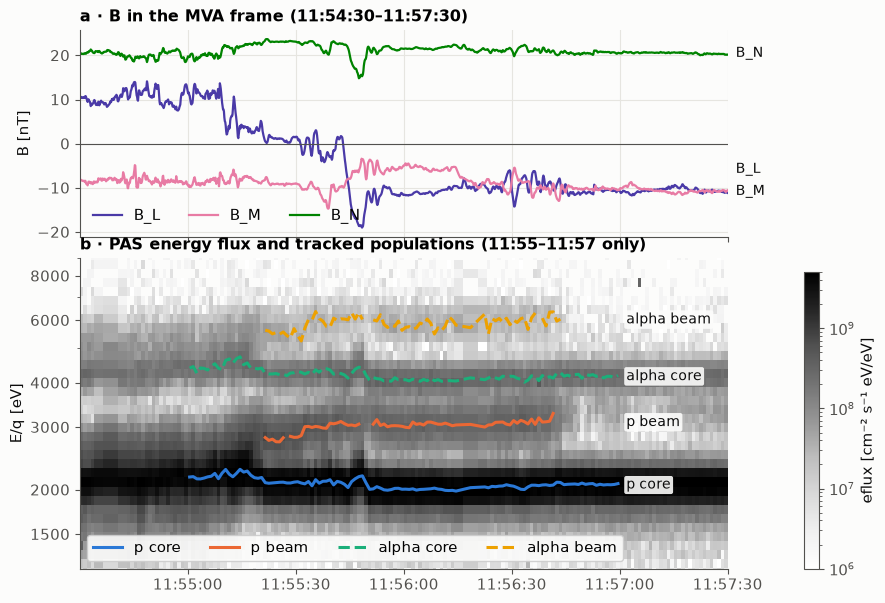

,first,last,detected (11:55–11:57)
proton beam,11:55:21,11:56:41,63%
alpha beam,11:55:13,11:56:52,67%


In [51]:
# Figure 1 — field rotation and the four populations in the PAS spectra
t0f, t1f = "2025-02-28T11:54:30", "2025-02-28T11:57:30"
b = spz.get_data(TREE.MAG.SOLO_L2_MAG_RTN_NORMAL.B_RTN, t0f, t1f)
basis, lam, _ = mva_basis(b, epoch(t0f), epoch(t1f))
blmn = np.asarray(b.values, float) @ basis.T
tE, E, F = pas_eflux(t0f, t1f)
inside = (tE >= ID_WINDOW_NS[0]) & (tE <= ID_WINDOW_NS[1])
tr = np.full((len(tE), 4), np.nan); tr[inside] = track_beams(E, F[inside])

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(11, 7), gridspec_kw=dict(height_ratios=[1, 1.5], hspace=0.08))
for i, lab in enumerate(BCOL):
    ax1.plot(b.time, blmn[:, i], color=BCOL[lab], lw=1.6, label=lab)
direct_labels(ax1, b.time[-1], [blmn[-200:, i].mean() for i in range(3)], list(BCOL), min_sep=5.0)
ax1.axhline(0, color=INK2, lw=0.8)
ax1.set_ylabel("B [nT]"); ax1.set_title("a · B in the MVA frame (11:54:30–11:57:30)")
ax1.legend(ncol=3, loc="lower left")

pc = ax2.pcolormesh(tE, E, np.where(F > 0, F, np.nan).T, norm=LogNorm(1e6, 5e9), cmap="Greys", shading="nearest")
for j, lab in enumerate(POP):
    ax2.plot(tE, tr[:, j], color=POP[lab], ls=POP_LS[lab], lw=2.2, label=lab)
t_end = tE[inside][-1]
direct_labels(ax2, t_end, [np.nanmedian(tr[inside, j][-40:]) for j in range(4)], list(POP), min_sep=0.06, log=True)
ax2.set_yscale("log"); ax2.set_ylim(1200, 9000); ax2.grid(False)
ax2.set_yticks([1500, 2000, 3000, 4000, 6000, 8000]); ax2.set_yticklabels(["1500", "2000", "3000", "4000", "6000", "8000"])
ax2.yaxis.set_minor_formatter(plt.NullFormatter())
ax2.set_ylabel("E/q [eV]"); ax2.set_title("b · PAS energy flux and tracked populations (11:55–11:57 only)")
cb = fig.colorbar(pc, ax=[ax1, ax2], shrink=0.55, anchor=(0, 0.0), pad=0.09); cb.set_label("eflux [cm⁻² s⁻¹ eV/eV]")
ax2.legend(ncol=4, loc="lower left", facecolor=SURF, framealpha=0.9, frameon=True)
display(fig); plt.close(fig)

first = lambda c: str(tE[np.isfinite(tr[:, c])][0])[11:19]
last  = lambda c: str(tE[np.isfinite(tr[:, c])][-1])[11:19]
display(pd.DataFrame({"first": [first(1), first(3)], "last": [last(1), last(3)],
                      "detected (11:55–11:57)": [f"{np.isfinite(tr[inside, c]).mean():.0%}" for c in (1, 3)]},
                     index=["proton beam", "alpha beam"]))

## 3 · Identifying protons and alphas in the PAS spectra
PAS measures energy per charge. A He²⁺ ion moving with a proton has **twice** its E/q, so a population is
identified as alphas when its E/q is ≈ 2× that of a proton population — and then its speed is
v = √(2·2e·(E/q)/(4 m_p)) = v_p(E/q)/√2. In 11:55–11:57 the four peaks line up as:

* proton core → alpha core at ×2.03: the cores co-move;
* proton beam → alpha beam at ×1.93: the beams co-move to within ~3 % in speed (≈ one energy step, dE/E ≈ 6 %).

In [52]:
tE, E, F = pas_eflux(*ID_WINDOW)
tr = track_beams(E, F)
v = {"p core": speed(tr[:, 0], 1, 1), "p beam": speed(tr[:, 1], 1, 1),
     "alpha core": speed(tr[:, 2], 4, 2), "alpha beam": speed(tr[:, 3], 4, 2)}
b = spz.get_data(TREE.MAG.SOLO_L2_MAG_RTN_NORMAL.B_RTN, *ID_WINDOW)
n = spz.get_data(TREE.SWA_PAS.SOLO_L2_SWA_PAS_GRND_MOM.N, *ID_WINDOW)
Bmed = np.nanmedian(np.linalg.norm(np.asarray(b.values), axis=1)); nmed = np.nanmedian(np.asarray(n.values))
vA = Bmed * 1e-9 / np.sqrt(cst.mu_0 * nmed * 1e6 * cst.m_p) / 1e3

display(pd.DataFrame({"E/q [eV]": [stat(tr[:, j]) for j in range(4)],
                      "speed [km/s]": [stat(v[k]) for k in POP],
                      "detected": [f"{np.isfinite(tr[:, j]).mean():.0%}" for j in range(4)]},
                     index=list(POP)))
display(pd.DataFrame({"value": [stat(v["p beam"] - v["p core"]), stat(v["alpha beam"] - v["alpha core"]),
                                f"{np.nanmedian(tr[:, 2] / tr[:, 0]):.2f}", f"{np.nanmedian(tr[:, 3] / tr[:, 1]):.2f}",
                                f"{vA:.0f}  (|B| {Bmed:.1f} nT, n {nmed:.1f} cm⁻³)"]},
                     index=["beam − core, protons [km/s]", "beam − core, alphas [km/s]",
                            "E/q alpha core / proton core", "E/q alpha beam / proton beam", "v_A [km/s]"]))

,E/q [eV],speed [km/s],detected
p core,2073 [2006–2179],630 [620–646],100%
p beam,3056 [2814–3120],765 [734–773],63%
alpha core,4196 [4057–4410],634 [623–650],100%
alpha beam,5906 [5494–6182],752 [725–770],67%


,value
"beam − core, protons [km/s]",140 [100–150]
"beam − core, alphas [km/s]",121 [90–138]
E/q alpha core / proton core,2.03
E/q alpha beam / proton beam,1.93
v_A [km/s],"141 (|B| 24.9 nT, n 14.8 cm⁻³)"


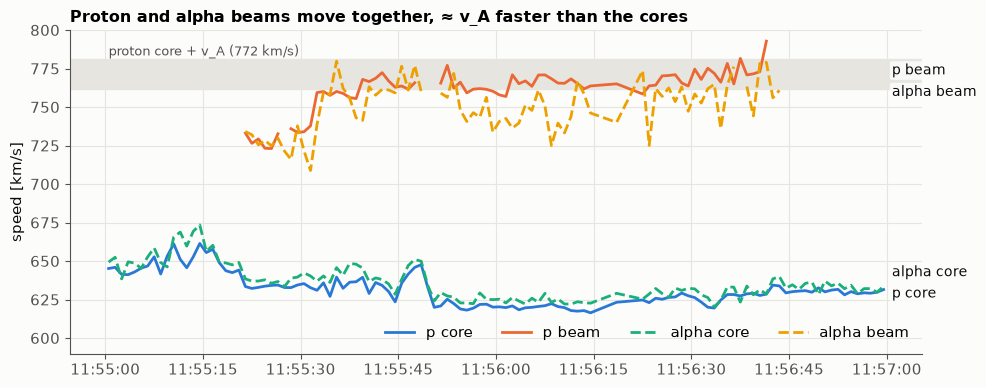

In [53]:
# Figure 2 — speeds of the four populations
fig, ax = plt.subplots(figsize=(11, 4.2))
for k in POP:
    ax.plot(tE, v[k], color=POP[k], ls=POP_LS[k], lw=2.0, label=k)
direct_labels(ax, tE[-1], [np.nanmedian(v[k][-40:]) for k in POP], list(POP), min_sep=14.0)
core = np.nanmedian(v["p core"])
ax.axhspan(core + vA - 10, core + vA + 10, color=GRID, zorder=0)
ax.annotate(f"proton core + v_A ({core + vA:.0f} km/s)", (tE[0], core + vA + 12), color=INK2, fontsize=9.5)
ax.set_ylabel("speed [km/s]"); ax.set_ylim(590, 800)
ax.set_title("Proton and alpha beams move together, ≈ v_A faster than the cores")
ax.legend(ncol=4, loc="lower right")
display(fig); plt.close(fig)

## 4 · 3D distributions in the field-aligned frame
**Adapter.** [sciqlop-vdf](https://github.com/nicolasaunai/sciqlop-vdf) started with MMS FPI only; its `sciqlop_vdf_solo` adapter adds SWA-PAS
(`SOLO_L2_SWA_PAS_VDF`, 11 azimuth × 9 elevation × 96 E/q, 1 s). Conventions established on these data:

* the angles are **look directions** (velocity = −look); `PAS_to_RTN` rows are the RTN axes in PAS coordinates;
* PAS sees ~64° × 45°: the angle table is surrounded by NaN guard bins so unseen directions stay empty;
* the archived f assumes **protons**. Re-read as He²⁺ (`PASSource("alpha")`): kinetic energy = 2 E/q,
  m = 4.0015 amu, f × 3.95 (f ∝ counts·v⁻⁴, v_α = v_p/√2).

The validation below integrates the proton part (E/q < 3.5 keV) and compares with the ground moments.

In [60]:
# The Solar Orbiter adapter ships with sciqlop-vdf >= 0.2.0 (https://github.com/nicolasaunai/sciqlop-vdf)
try:
    import sciqlop_vdf_solo.pas as pas
    import sciqlop_vdf_solo.sources as solo_sources
except ImportError as e:
    raise ImportError("Section 4 needs sciqlop-vdf >= 0.2.0: install "
                      "'sciqlop-vdf @ git+https://github.com/nicolasaunai/sciqlop-vdf' in this workspace, "
                      "then restart SciQLop") from e
import sciqlop_vdf.core.pipeline as vpipe
import sciqlop_vdf.ui.controller as vctl
solo_sources.register()   # idempotent: the plugin already registers its sources at start-up

In [55]:
# Validation: moments of the PAS VDF (proton part) vs SOLO_L2_SWA_PAS_GRND_MOM, 11:55–11:57
import pycdfpp
from speasy.core.any_files import any_loc_open
url = pas._day_urls(epoch(ID_WINDOW[0]), epoch(ID_WINDOW[1]))[0]
day = pas._CACHE.get(url, pas._load_day)
cdf = pycdfpp.load(any_loc_open(url, cache_remote_files=True).read())     # lazy: only the small tables are read below
dAZ, dEL = (np.asarray(cdf[k].values, float).ravel() for k in ("delta_Azimuth", "delta_Elevation"))
dE = np.asarray(cdf["delta_p_Energy"].values, float).ravel() + np.asarray(cdf["delta_m_Energy"].values, float).ravel()
sel = (day["time_s"] >= epoch(ID_WINDOW[0])) & (day["time_s"] <= epoch(ID_WINDOW[1]))
Fm = np.asarray(day["f"][sel], float); M = day["pas_to_rtn"][sel]
Eq, az, el = day["energy"], np.deg2rad(day["azimuth"]), np.deg2rad(day["elevation"])
Fm[..., Eq >= 3500.0] = 0.0
look = np.stack([np.cos(el)[None] * np.cos(az)[:, None], np.cos(el)[None] * np.sin(az)[:, None],
                 np.broadcast_to(np.sin(el)[None], (az.size, el.size))], -1)
dOm = (2 * np.deg2rad(dAZ))[:, None] * (2 * np.deg2rad(dEL))[None] * np.cos(el)[None]
vb = np.sqrt(2 * cst.e * Eq / cst.m_p); w = vb ** 2 * vb * dE / (2 * Eq)
dens = np.einsum("taje,aj,e->t", Fm, dOm, w)
V_rtn = np.einsum("tij,tj->ti", M, -np.einsum("taje,aj,e,ajk->tk", Fm, dOm, w * vb, look) / dens[:, None] / 1e3)
t_vdf = (day["time_s"][sel] * 1e9).astype("datetime64[ns]")
mn = spz.get_data(TREE.SWA_PAS.SOLO_L2_SWA_PAS_GRND_MOM.N, *ID_WINDOW); mv = spz.get_data(TREE.SWA_PAS.SOLO_L2_SWA_PAS_GRND_MOM.V_RTN, *ID_WINDOW)
ti = lambda t: t.astype("datetime64[ns]").astype(np.int64)
ref_n = np.interp(ti(t_vdf), ti(mn.time), np.asarray(mn.values)[:, 0])
ref_v = np.stack([np.interp(ti(t_vdf), ti(mv.time), np.asarray(mv.values)[:, i]) for i in range(3)], 1)
ang = np.degrees(np.arccos(np.clip(np.sum(V_rtn * ref_v, 1) / np.linalg.norm(V_rtn, axis=1) / np.linalg.norm(ref_v, axis=1), -1, 1)))
display(pd.DataFrame({"VDF moments": [f"{np.median(dens) / 1e6:.1f}", str(np.round(np.median(V_rtn, 0)).tolist())],
                      "ground moments": [f"{np.median(ref_n):.1f}", str(np.round(np.median(ref_v, 0)).tolist())],
                      "agreement": [f"ratio {np.median(dens / 1e6 / ref_n):.2f}",
                                    f"|V| ratio {np.median(np.linalg.norm(V_rtn, axis=1) / np.linalg.norm(ref_v, axis=1)):.3f}, angle {np.median(ang):.1f}°"]},
                     index=["n [cm⁻³]", "V_RTN [km/s]"]))
del Fm, cdf

,VDF moments,ground moments,agreement
n [cm⁻³],16.9,14.8,ratio 1.11
V_RTN [km/s],"[628.0, -31.0, 7.0]","[605.0, -17.0, 0.0]","|V| ratio 1.041, angle 3.3°"


### The VDF panel
Spectrogram with the tracked populations · beam speeds · field-aligned distributions (bulk frame,
reduced planes) at the orange marker. Drag the marker to step through the 1 s distributions, or switch the
control bar to *interval* to average (the marker is then ignored).

In [59]:
vp = fresh_panel("SolO_PAS_VDF")
vp.plot_product("solo//pas_eflux_spectro")
vp.plot_product("solo//pas_beam_speeds")
vp.time_range = TimeRange(*ID_WINDOW)              # after plotting: plotting resets the range
spec, spd = vp.plots[0], vp.plots[1]
spec.legend_visible = False
spec.plot("solo//pas_beam_energies", y_axis="y2")
vp.wait_for_data(120)
spec.set_axis_label("y", ""); spec.set_axis_tick_labels("y", {-1e9: ""})
style_graph(vp.name, 0, "pas_beam_energies", 2.5, ["white", "magenta", "black", "magenta"],
            [Qt.SolidLine, Qt.SolidLine, Qt.SolidLine, Qt.DashLine])
style_graph(vp.name, 1, "pas_beam_speeds", 2.5, ["magenta", "darkviolet"], [Qt.SolidLine, Qt.DashLine])
spd.set_axis_label("y", "beam speed", "km/s"); spd.legend_visible = False; spd.set_y_range(680, 820)
labels = [Text(spd, "— proton beam", 70, 4, color="magenta", coordinate_system=CoordinateSystem.Pixel),
          Text(spd, "- - alpha beam (He++)", 70, 20, color="darkviolet", coordinate_system=CoordinateSystem.Pixel)]
vdf = vctl.attach(vp, pas.PASSource("proton"),
                  vpipe.Options(frame="field-aligned", bulk_frame=True, vmax=700.0), t=epoch(MARKER_T))
print("panel", vp.name, "| VDF", vdf.mode, vdf.options.frame)

panel SolO_PAS_VDF | VDF marker field-aligned


**Reading the distribution.** In the archived (proton-mass) view the four populations sit along v∥ at
0 (proton core), ≈ +145 (proton beam), ≈ +255 (alpha core) and ≈ +430 km/s (alpha beam): the alphas appear
at √2 × their speed. Re-read as He²⁺ (E/q ≥ 3.6 keV), the alpha core moves to ≈ 0 and the alpha beam to
≈ +135 km/s — next to the proton beam. Figure 3 averages 11:55:25–11:56:35 (70 distributions).

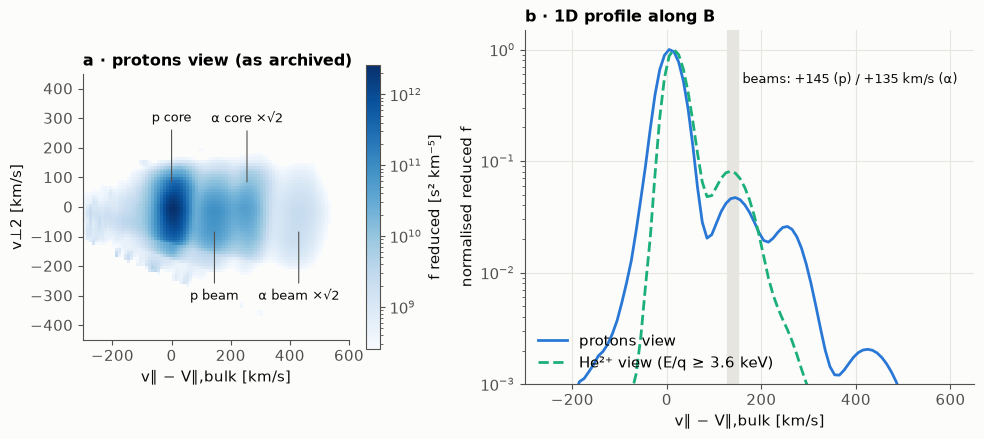

,v∥ peaks [km/s]
view,
protons view,"[5, 145, 255, 425]"
He²⁺ view,"[15, 135]"


In [57]:
# Figure 3 — averaged field-aligned distributions
opts = vpipe.Options(frame="field-aligned", bulk_frame=True, vmax=700.0, grid_n=140)
a0, a1 = epoch(AVG_WINDOW[0]), epoch(AVG_WINDOW[1])
bp = pas.PASSource("proton").get(a0 - 2, a1 + 2)
ba = pas.PASSource("alpha", min_e_per_q=E_SPLIT).get(a0 - 2, a1 + 2)
Pp = vpipe.compute_planes(bp, a0, a1, opts)
Pa = vpipe.compute_planes(ba, a0, a1, opts)
del bp, ba

def profile(P):
    x = np.asarray(P.planes[1].x); prof = np.nan_to_num(np.asarray(P.planes[1].z, float)).sum(axis=1)
    return x, prof / prof.max()

fig = plt.figure(figsize=(11.5, 4.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.28)
ax = fig.add_subplot(gs[0])
p1 = Pp.planes[1]
zmax = np.nanmax(p1.z)
im = ax.pcolormesh(p1.x, p1.y, np.where(p1.z > zmax / 1e4, p1.z, np.nan).T, cmap="Blues",
                   norm=LogNorm(zmax / 1e4, zmax), shading="nearest")
ax.set_aspect("equal"); ax.grid(False); ax.set_xlim(-300, 600); ax.set_ylim(-450, 450)
ax.set_xlabel("v∥ − V∥,bulk [km/s]"); ax.set_ylabel("v⊥2 [km/s]"); ax.set_title("a · protons view (as archived)")
fig.colorbar(im, ax=ax, shrink=0.8).set_label("f reduced [s² km⁻⁵]")
for xv, lab, yv in ((0, "p core", 300), (145, "p beam", -300), (255, "α core ×√2", 300), (430, "α beam ×√2", -300)):
    ax.annotate(lab, (xv, 0), xytext=(xv, yv), ha="center", va="center", fontsize=9, color=INK,
                arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8, shrinkB=18))

ax = fig.add_subplot(gs[1])
for P, lab, col, ls in ((Pp, "protons view", POP["p core"], "-"), (Pa, "He²⁺ view (E/q ≥ 3.6 keV)", POP["alpha core"], "--")):
    x, pr = profile(P)
    ax.semilogy(x, pr, color=col, ls=ls, lw=2.0, label=lab)
ax.set_ylim(1e-3, 1.5); ax.set_xlim(-300, 650)
ax.set_xlabel("v∥ − V∥,bulk [km/s]"); ax.set_ylabel("normalised reduced f"); ax.set_title("b · 1D profile along B")
for xv, lab in ((145, "p beam"), (135, "α beam\n(He²⁺ view)")):
    ax.axvline(xv, color=GRID, lw=6, zorder=0)
ax.annotate("beams: +145 (p) / +135 km/s (α)", (160, 0.5), color=INK, fontsize=9.5)
ax.legend(loc="lower left")
display(fig); plt.close(fig)

rows = []
for P, name in ((Pp, "protons view"), (Pa, "He²⁺ view")):
    x, pr = profile(P)
    pk, prm = find_peaks(np.log10(pr + 1e-30), prominence=0.1)
    keep = (x[pk] > -250) & (x[pk] < 600)
    rows.append({"view": name, "v∥ peaks [km/s]": np.round(x[pk][keep]).astype(int).tolist()})
display(pd.DataFrame(rows).set_index("view"))

## 5 · Interpretation
* Within 11:55:21–11:56:41 PAS resolves a **proton beam and an alpha beam moving at the same speed**
  (765 vs 752 km/s, ratio of E/q 1.93 ≈ 2), **≈ v_A faster than their cores** (+140 / +121 km/s vs v_A = 141 km/s),
  **along +B** (Δv∥ ≈ +145 / +135 km/s in the field-aligned VDF), while B_L reverses.
* Co-moving proton and alpha beams offset by ≈ v_A along B inside a field reversal are the expected signature of a
  **reconnection exhaust** in the solar wind (Gosling et al. 2005, *JGR* 110, A01107). This is an inference from the
  energy spectra and the distributions; it has not been tested here.

**Next steps**
1. Walén test: ΔV vs ±ΔB/√(μ₀ρ) on each side of the reversal (needs a reliable L only, which MVA gives).
2. Normal: constrained MVA (⟨B_N⟩ = 0) or cross-product normal; MVA per step of the reversal.
3. `SOLO_L2_MAG_RTN_BURST` (128 vec/s, continuous here) for the internal structure of the three steps.
4. Check the second, weaker proton beam at ≈ 11:57:40–11:58:10.

## Caveats
* **MVA:** λ_int/λ_min ≈ 2 → N/M degenerate; only L is used.
* **Energies:** eflux ∝ E² f pushes peak energies ~10 % (1–2 bins) above ½ m V² for cores and beams alike;
  speed *differences* are affected far less. dE/E ≈ 6 % (≈ 3 % in speed).
* **VDF vs ground moments:** direction 3.3°, |V| +4 %, n +11 % (proton part). Cause of the offset not identified.
* **VDF grid:** 1-D azimuth/elevation tables (instrument azimuths vary with elevation by ≤ 2°); per-energy elevation
  correction (≤ 0.83°) ignored; no one-count level in the L2 VDF.
* **Species split:** E/q = 3.6 keV is specific to this interval.
* **v_A** uses the proton mass density only (alphas lower it by a few %).

## Provenance
| | |
|---|---|
| data | CDAWeb via speasy: `SOLO_L2_MAG_RTN_NORMAL`, `SOLO_L2_SWA_PAS_GRND_MOM`, `SOLO_L2_SWA_PAS_EFLUX`, `SOLO_L2_SWA_PAS_VDF` (v02), `SOLO_L3_SWA_EAS_NMPAD_PSD` |
| code | this notebook; [sciqlop-vdf](https://github.com/nicolasaunai/sciqlop-vdf) ≥ 0.2.0 (generic core + MMS FPI and SolO SWA-PAS adapters, 102 offline tests) |
| issues | speasy L2 EAS PAD loading: [SciQLop/speasy#399](https://github.com/SciQLop/speasy/issues/399) |
| source | "Event context" slide, N. Fargette & the PAS team, Arcachon 2026 |